In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from Pcm import find_model
import globals as gl
import matplotlib.patches as patches
import PcmPy as pcm
from scipy.stats import ttest_1samp
import pickle

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


Text(0.5, 0.98, 'Execution models (distance)')

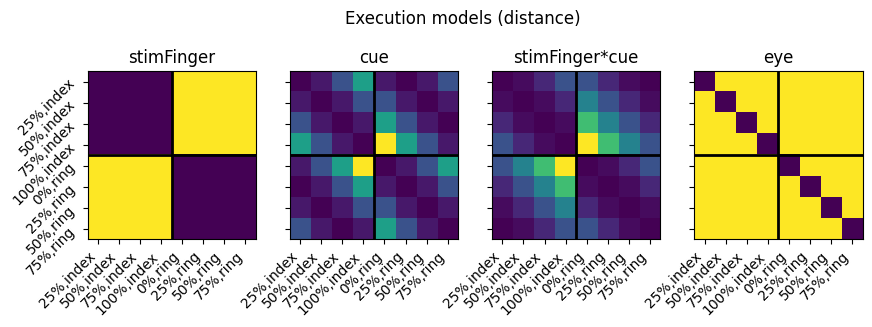

In [2]:
C = pcm.centering(8)

v_fingerID = C @ np.array([1, 1, 1, 1, -1, -1, -1, -1])
v_cue = C @ np.array([-1, 0, 1, 2, -2, -1, 0, 1, ])
v_fingerID_by_cue = C @ (v_fingerID + v_cue)

G_fingerID = np.outer(v_fingerID, v_fingerID)
G_cue = np.outer(v_cue, v_cue)
G_fingerID_by_cue = np.outer(v_fingerID_by_cue, v_fingerID_by_cue)

fig, axs = plt.subplots(1, 4, sharex=True, sharey=True, figsize=(10, 3))

axs[0].imshow(pcm.G_to_dist(G_fingerID))
axs[1].imshow(pcm.G_to_dist(G_cue))
axs[2].imshow(pcm.G_to_dist(G_fingerID_by_cue))
axs[3].imshow(pcm.G_to_dist(np.eye(8)))

axs[0].set_title('stimFinger')
axs[1].set_title('cue')
axs[2].set_title('stimFinger*cue')
axs[3].set_title('eye')

for ax in axs:
    ax.axvline(3.5, color='k', ls='-', lw=2)
    ax.axhline(3.5, color='k', ls='-', lw=2)
    ax.set_xticks(np.arange(8))
    ax.set_xticklabels(list(gl.regressor_mapping.keys())[5:], rotation=45, ha='right')
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(list(gl.regressor_mapping.keys())[5:], rotation=45, ha='right')

fig.suptitle('Execution models (distance)')

Text(0.5, 0.98, 'Squared distance between force patterns')

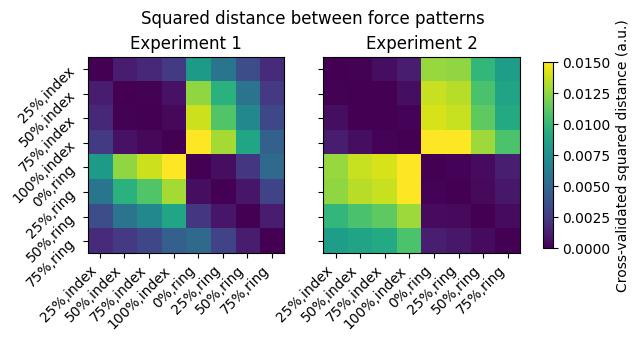

In [3]:
experiment = ['smp0', 'smp2']

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(6, 3))

vmin, vmax = 0, .015

for ax, exp in zip(axs, experiment):
    G_obs = np.load(os.path.join(gl.baseDir, exp, gl.pcmDir, 'G_obs.force.npy'))
    D = np.zeros_like(G_obs)
    for g, G in enumerate(G_obs):
        D[g] = pcm.G_to_dist(G)

    cond = list(gl.regressor_mapping.keys())[5:]

    cax = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(len(cond)))
    ax.set_yticks(np.arange(len(cond)))
    ax.set_xticklabels(cond, rotation=45, ha='right')
    ax.set_yticklabels(cond, rotation=45, ha='right')

    ax.set_title(f'Experiment {experiment.index(exp) + 1}')

cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.02)
cbar.set_label('Cross-validated squared distance (a.u.)')

fig.suptitle(f'Squared distance between force patterns')

# fig.subplots_adjust(left=0.2, right=0.8, top=.8, bottom=0.4, wspace=0.3)

P-values (Experiment 1):
stimFinger                                0.00000
cue                                       0.00009
eye                                       0.00000
stimFinger+cue (component)                0.00000
stimFinger+cue+stimFinger*cue (feature)   0.00000
	
P-values (Experiment 2):
stimFinger                                0.00000
cue                                       0.00003
eye                                       0.00000
stimFinger+cue (component)                0.00000
stimFinger+cue+stimFinger*cue (feature)   0.00000
	


Text(0.5, 0.98, 'Normalized marginal likelihood')

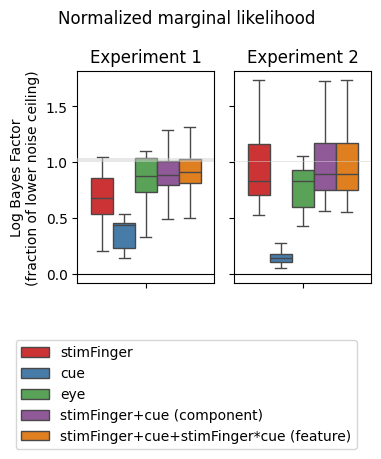

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import matplotlib.patches as patches

experiment = ['smp0', 'smp2']

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(4, 3))

legend_handles = []  # To collect handles for the legend
legend_labels = []

for ax, exp in zip(axs, experiment):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, exp, gl.pcmDir, 'T_cv.force.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, exp, gl.pcmDir, 'T_gr.force.pkl'))

    likelihood = T_cv.likelihood
    baseline = likelihood.loc[:, 'null'].values
    likelihood = likelihood - baseline.reshape(-1, 1)

    noise_upper = (T_gr.likelihood['ceil'] - baseline).mean()
    noise_lower_abs = likelihood.ceil.mean()
    likelihood = likelihood / noise_lower_abs
    noise_upper = noise_upper / noise_lower_abs
    noise_lower = likelihood.ceil.mean()

    LL = pd.melt(likelihood)
    LL['noise_lower'] = noise_lower
    LL['noise_upper'] = noise_upper

    LL = LL[(LL['model'] == 'stimFinger') |
            (LL['model'] == 'cue') |
            (LL['model'] == 'eye') |
            (LL['model'] == 'stimFinger+cue (component)') |
            (LL['model'] == 'stimFinger+cue+stimFinger*cue (feature)')]

    _, pval = ttest_1samp(likelihood[[
        'stimFinger',
        'cue',
        'eye',
        'stimFinger+cue (component)',
        'stimFinger+cue+stimFinger*cue (feature)'
    ]], popmean=0)

    pval_series = pd.Series(pval, index=[
        'stimFinger',
        'cue',
        'eye',
        'stimFinger+cue (component)',
        'stimFinger+cue+stimFinger*cue (feature)'
    ])

    # Print formatted p-values
    print(f"P-values (Experiment {experiment.index(exp) + 1}):")
    print(pval_series.to_string(float_format="%.5f"))
    print('\t')

    # Boxplot
    box = sns.boxplot(ax=ax, hue='model', y='value', data=LL, showfliers=False,
                      hue_order=['stimFinger', 'cue', 'eye','stimFinger+cue (component)', 'stimFinger+cue+stimFinger*cue (feature)'],
                      palette='Set1')

    # Collect handles and labels only once (from the last plot)
    if not legend_handles:
        legend_handles, legend_labels = box.get_legend_handles_labels()

    ax.axhline(0, color='k', ls='-', lw=.8)

    nl = LL['noise_lower'].unique()[0]
    nu = LL['noise_upper'].unique()[0]

    noiserect = patches.Rectangle((-.5, nl), 6, nu-nl, linewidth=0, facecolor='lightgrey', zorder=1e6, alpha=.5)
    ax.add_patch(noiserect)

    ax.set_ylabel('Log Bayes Factor\n(fraction of lower noise ceiling)')
    ax.set_xlabel('')

    ax.set_title(f'Experiment {experiment.index(exp) + 1}')

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    # Remove individual legends
    ax.get_legend().remove()

# Add a single figure-level legend
fig.legend(legend_handles, legend_labels,  loc="upper center",
           bbox_to_anchor=(.5, -.1), ncol=1)

fig.tight_layout(rect=[0, 0, 1, .9])  # Leave space for the legend
fig.suptitle('Normalized marginal likelihood')


P-values (Experiment 1):
stimFinger   0.00000
cue          0.00000
	
P-values (Experiment 2):
stimFinger   0.00000
cue          0.00000
	


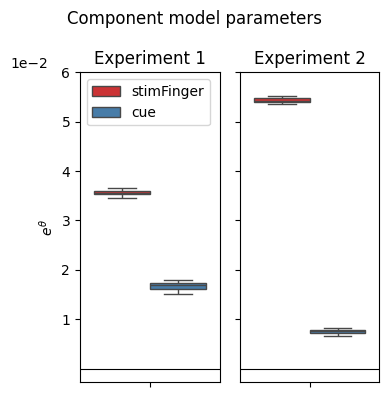

In [91]:
experiment = ['smp0', 'smp2']

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(4, 4))

legend_handles, legend_labels = None, None  # To store legend info

alpha = .5

for ax, exp in zip(axs, experiment):
    M, idx = find_model(os.path.join(gl.baseDir, exp, gl.pcmDir, 'M.force.pkl'), 'stimFinger+cue (component)')
    f = open(os.path.join(gl.baseDir, exp, gl.pcmDir, 'theta_cv.force.pkl'), "rb")
    theta_tmp = pickle.load(f)[idx][:M.n_param]

    theta_exp = np.exp(theta_tmp.flatten())

    theta = {
        'theta': theta_exp**alpha,
        'sn': np.tile(np.arange(theta_tmp.shape[1]), M.n_param),
        'model': [mdl for mdl in components for _ in range(theta_tmp.shape[1])]
    }

    theta = pd.DataFrame(theta)

    _, pval = ttest_1samp(theta_tmp.T, popmean=0)

    pval_series = pd.Series(pval, index=[
        'stimFinger',
        'cue',
    ])

    # Print formatted p-values
    print(f"P-values (Experiment {experiment.index(exp) + 1}):")
    print(pval_series.to_string(float_format="%.5f"))
    print('\t')

    # Create boxplot
    box = sns.boxplot(ax=ax, data=theta, y='theta', hue='model', showfliers=False, palette='Set1')

    # Store legend handles and labels (only once)
    if legend_handles is None:
        legend_handles, legend_labels = box.get_legend_handles_labels()

    ax.set_ylabel(r"$e^{\theta}$")
    ax.axhline(0, color='k', ls='-', lw=.8)

    y_ticks = np.array([0.0001, 0.0004, 0.0009, 0.0016, 0.0025, 0.0036])    # Original scale
    ax.set_yticks(y_ticks**alpha)  # Set transformed positions
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.get_yaxis().offsetText.set_x(-.5)

    ax.set_title(f'Experiment {experiment.index(exp) + 1}')

    # Remove individual subplot legends
    ax.get_legend().remove()

fig.suptitle('Component model parameters')

# Add a single figure-level legend
axs[0].legend(legend_handles, legend_labels, loc="upper left", ncol=1)
fig.tight_layout(rect=[0, 0, 1, 1])

P-values (Experiment 1):
stimFinger       0.00000
cue              0.00000
stimFinger*cue   0.00000
	
P-values (Experiment 2):
stimFinger       0.00000
cue              0.00000
stimFinger*cue   0.00000
	


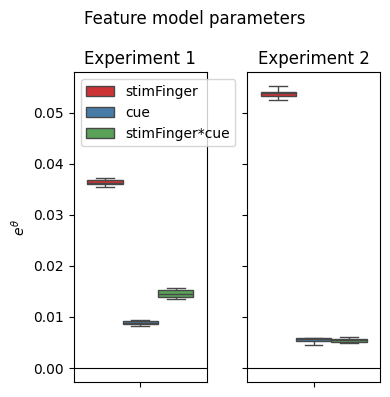

In [92]:
experiment = ['smp0', 'smp2']

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(4, 4))

legend_handles, legend_labels = None, None  # To store legend info

alpha = .5

for ax, exp in zip(axs, experiment):
    M, idx = find_model(os.path.join(gl.baseDir, exp, gl.pcmDir, 'M.force.pkl'), 'stimFinger+cue+stimFinger*cue (feature)')
    f = open(os.path.join(gl.baseDir, exp, gl.pcmDir, 'theta_cv.force.pkl'), "rb")
    theta_tmp = pickle.load(f)[idx][:M.n_param]

    theta = {
        'theta': theta_tmp.flatten(),
        'sn': np.tile(np.arange(theta_tmp.shape[1]), M.n_param),
        'model': np.repeat(M.name.split(' ')[0].split('+'), theta_tmp.shape[1]),
    }

    theta = pd.DataFrame(theta)

    _, pval = ttest_1samp(theta_tmp.T, popmean=0)

    pval_series = pd.Series(pval, index=[
        'stimFinger',
        'cue',
        'stimFinger*cue'
    ])

    # Print formatted p-values
    print(f"P-values (Experiment {experiment.index(exp) + 1}):")
    print(pval_series.to_string(float_format="%.5f"))
    print('\t')

    # Create boxplot
    box = sns.boxplot(ax=ax, data=theta, y='theta', hue='model', showfliers=False, palette='Set1')

    # Store legend handles and labels (only once)
    if legend_handles is None:
        legend_handles, legend_labels = box.get_legend_handles_labels()

    ax.set_ylabel(r"$e^{\theta}$")
    ax.axhline(0, color='k', ls='-', lw=.8)

    ax.set_title(f'Experiment {experiment.index(exp) + 1}')

    # Remove individual subplot legends
    ax.get_legend().remove()

fig.suptitle('Feature model parameters')

# Add a single figure-level legend
axs[0].legend(legend_handles, legend_labels, loc="upper left", ncol=1)
fig.tight_layout(rect=[0, 0, 1, 1])